#Segment Shopping Customers

#Problem Statement: Understand the Target Customers for the marketing team to plan a strategy
The goal is to identify the most important shopping groups based on income, age, and the mall shopping score

In this project, we identify the most important shopping groups based on income, age, and the mall shopping score to  Understand the Target Customers for the marketing team to plan a strategy.






In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv("C:/Users/itumeleng.ramala/OneDrive - MultiChoice/PDP/Python/Mall_Customers.csv")  #Import the data set

In [33]:
df.head()   #Returns top 5 rows

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#Univariate Analysis

In [34]:
df.describe()  #Gives a summary of the data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


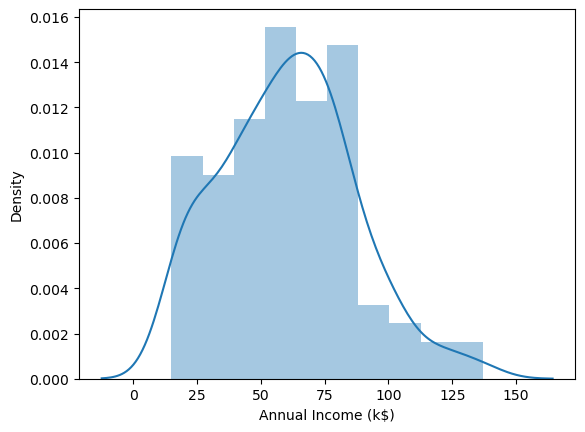

In [35]:
sns.distplot(df['Annual Income (k$)']);

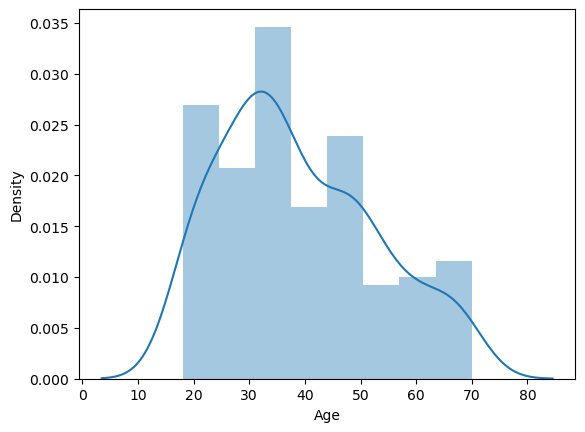

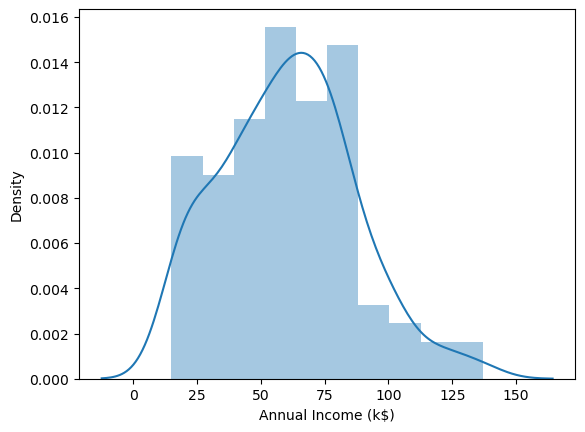

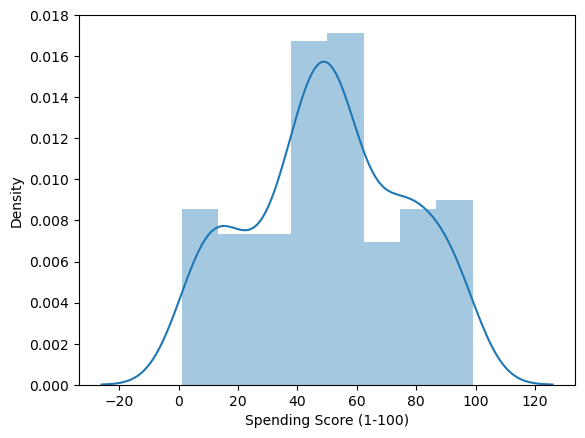

In [36]:
columns = ['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']

for i in columns:
    plt.figure()     #Create a new figure
    sns.distplot(df[i])   #Plots a histogram for each variable

In [37]:
df['Gender']

0        Male
1        Male
2      Female
3      Female
4      Female
        ...  
195    Female
196    Female
197      Male
198      Male
199      Male
Name: Gender, Length: 200, dtype: object

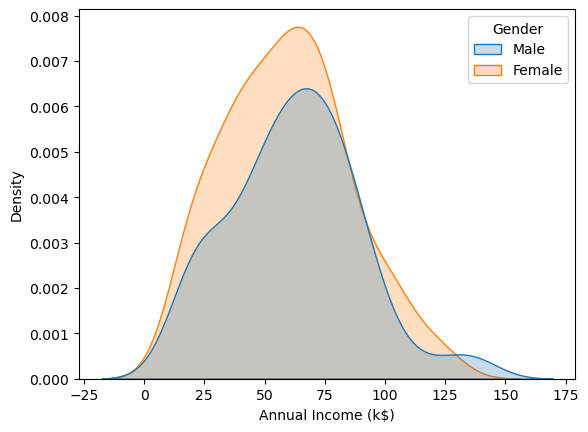

In [38]:
sns.kdeplot(data=df, x='Annual Income (k$)', hue='Gender', shade=True);


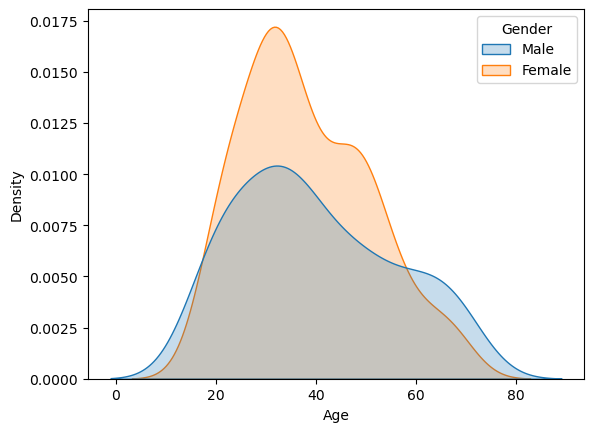

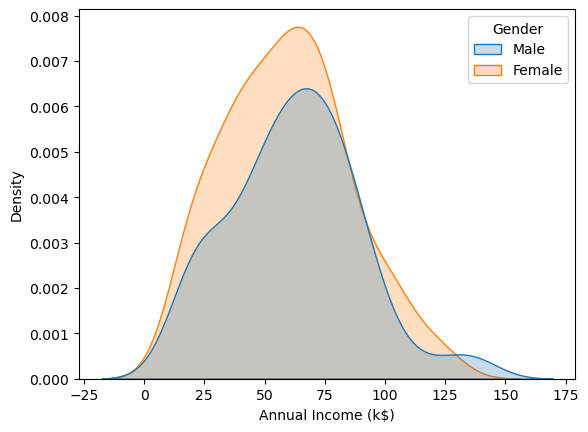

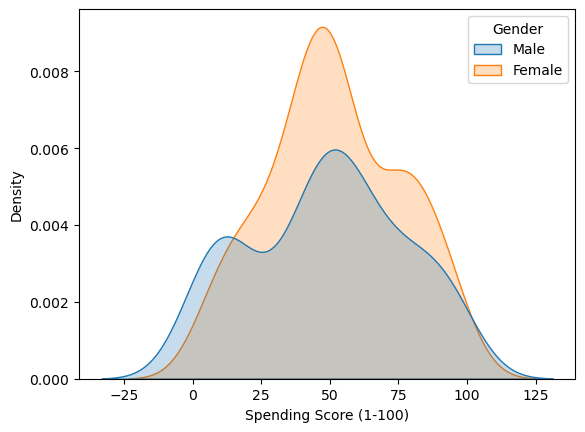

In [39]:
columns = ['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']

for i in columns:
    plt.figure()     #Create a new figure
    sns.kdeplot(data=df, x=i, hue='Gender', shade=True);

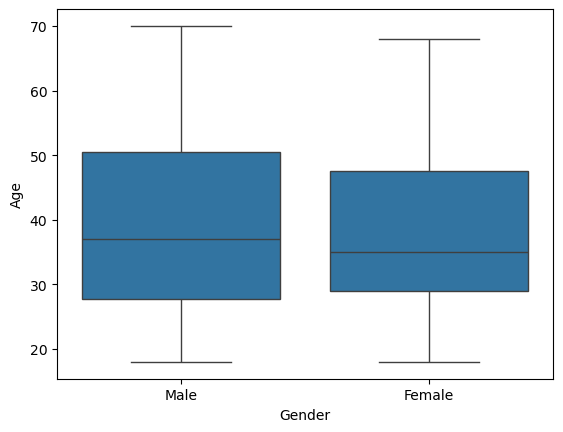

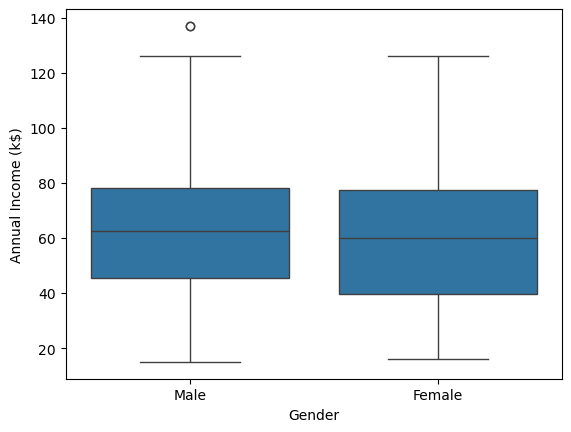

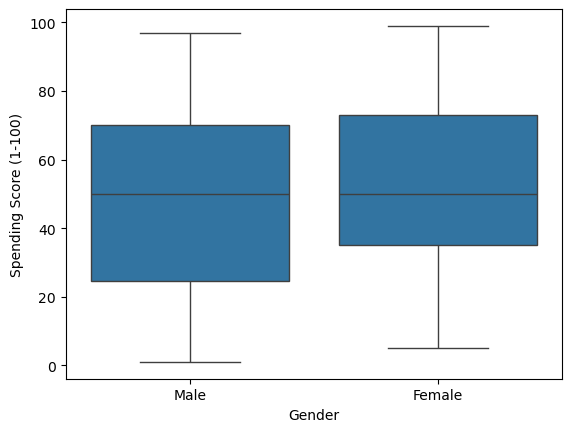

In [40]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)'];

for i in columns: 
    plt.figure()     #Create a new figure
    sns.boxplot(data=df, x='Gender', y=df[i]);

In [41]:
df['Gender'].value_counts(normalize=True)  #Look at the gender proportion

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

#Bivariate Analysis

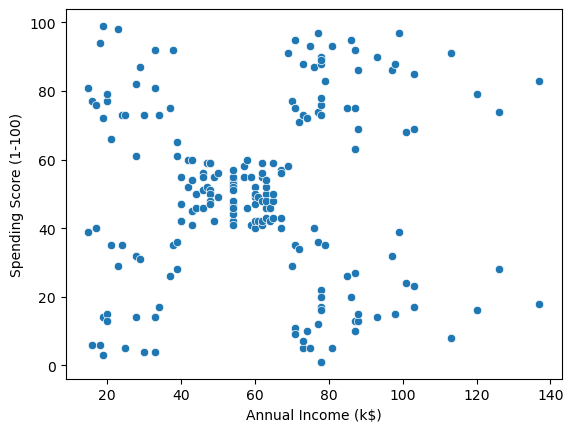

In [42]:
sns.scatterplot(data = df,x='Annual Income (k$)',y=df['Spending Score (1-100)']);

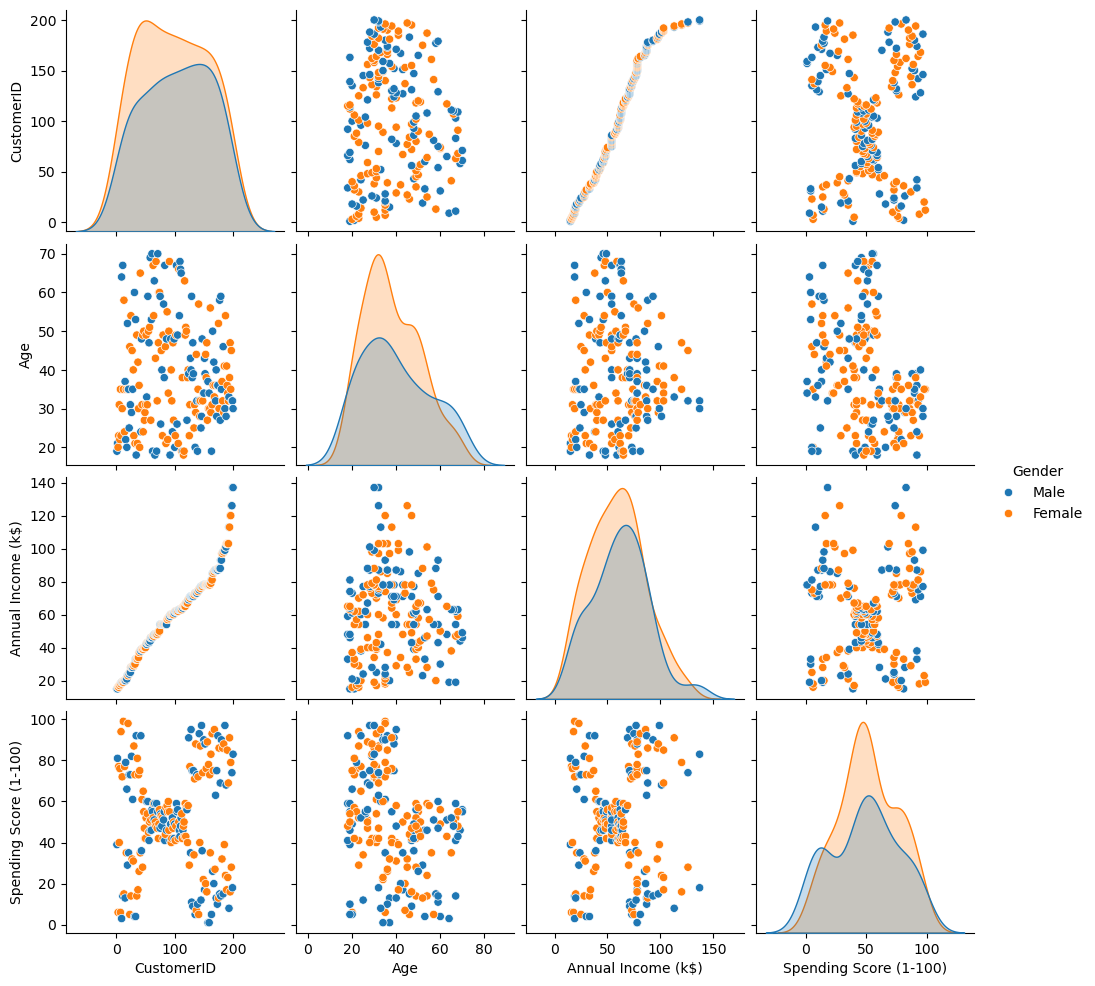

In [43]:
#df=df.drop('CustomerID',axis=1);
sns.pairplot(df,hue='Gender')

In [44]:
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [45]:
df.corr(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


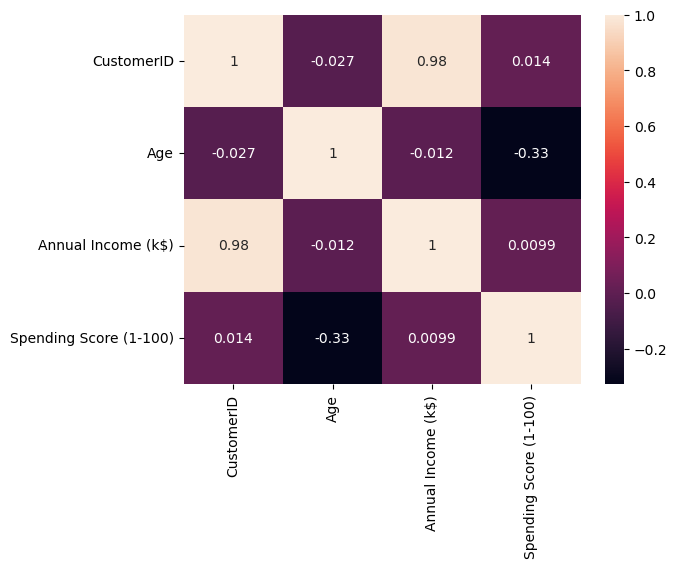

In [46]:
sns.heatmap(df.corr(numeric_only=True),annot=True); #Get correlation between variables

#Clustering - Univariate, Bivariate, Multivariate

#Univariate

In [47]:
clustering1 = KMeans(n_clusters=3)

In [48]:
clustering1.fit(df[['Annual Income (k$)']])

KMeans(n_clusters=3)

In [49]:
clustering1.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [50]:
df['Income Cluster'] = clustering1.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [51]:
df['Income Cluster'].value_counts()

Income Cluster
0    86
2    58
1    56
Name: count, dtype: int64

In [52]:
clustering1.inertia_

25640.457784396833

In [53]:
Inertia_Scores=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)']])
    Inertia_Scores.append(kmeans.inertia_)

In [54]:
Inertia_Scores

[137277.28000000003,
 49761.73701298701,
 25640.457784396833,
 13491.06700476633,
 9437.491391649288,
 5503.407059314954,
 4446.432748538013,
 3566.1119880119877,
 2340.5970715558956,
 1846.2830808080812]

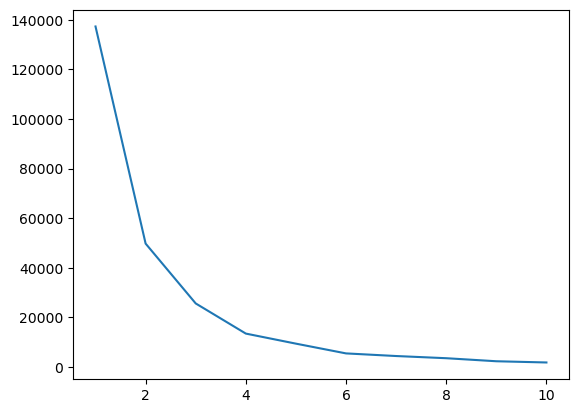

In [55]:
plt.plot(range(1,11),Inertia_Scores)

In [56]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Income Cluster'],
      dtype='object')

In [58]:
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,41.279070,60.906977,50.337209
1,36.910714,92.142857,50.517857
2,37.120690,29.551724,49.689655


#Bivariate

In [63]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,2,3
1,2,Male,21,15,81,2,4
2,3,Female,20,16,6,2,3
3,4,Female,23,16,77,2,4
4,5,Female,31,17,40,2,3


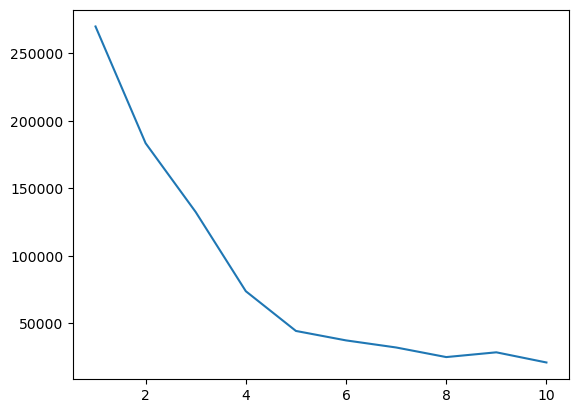

In [64]:
Inertia_Scores2=[]
for i in range(1,11):
    kmeans2 = KMeans(n_clusters=i)
    kmeans2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    Inertia_Scores2.append(kmeans2.inertia_)
plt.plot(range(1,11),Inertia_Scores2)

In [74]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['X','Y']
centers

,X,Y
0,88.200000,17.114286
1,55.296296,49.518519
2,86.538462,82.128205
3,26.304348,20.913043
4,25.727273,79.363636


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

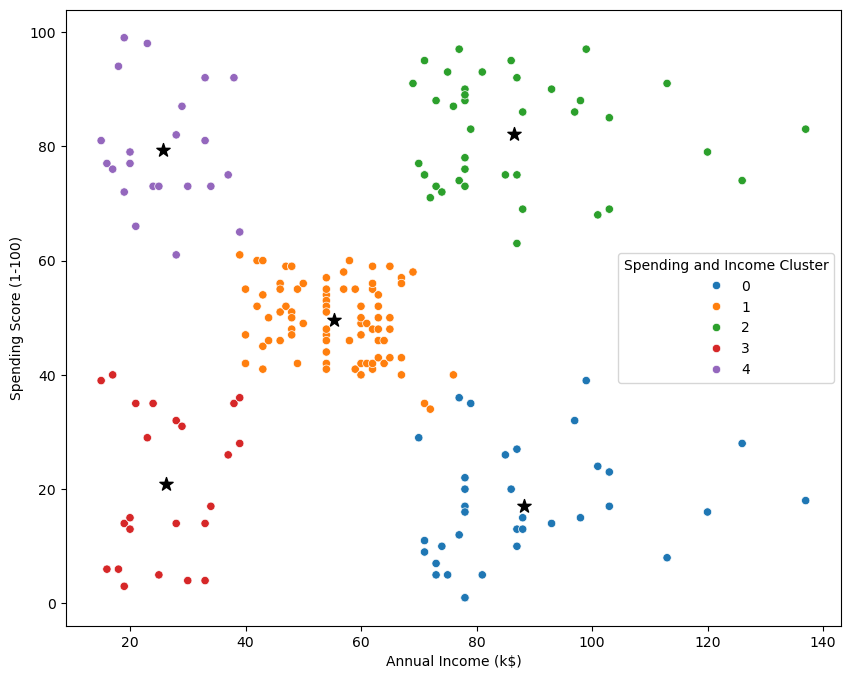

In [ ]:
plt.figure(figsize=(10,8))   #make the figure bigger
plt.scatter(x=centers['X'],y =centers['Y'],s=100,c='black',marker='*') #Adding centers to the scatterplot
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Spending and Income Cluster',palette='tab10') #Plot the 2 variables

#Comments for presentation

1. Target group is cluster 2 which has high Spending Score and high income. 
2. 53 percent of cluster 2 shoppers are women and we should look for ways to attract this customers usning marketing campaigns
3. Cluster 2 presents an interesting opportunity to market the customers for sales event on popular items

In [78]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'],normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.457143,0.542857
1,0.592593,0.407407
2,0.538462,0.461538
3,0.608696,0.391304
4,0.590909,0.409091


In [79]:
df.groupby('Spending and Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,41.114286,88.200000,17.114286
1,42.716049,55.296296,49.518519
2,32.692308,86.538462,82.128205
3,45.217391,26.304348,20.913043
4,25.272727,25.727273,79.363636


#multivariate Clustering



In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
scale = StandardScaler()

In [84]:
dff = pd.get_dummies(df,drop_first=True)
dff.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,1,19,15,39,2,3,True
1,2,21,15,81,2,4,True
2,3,20,16,6,2,3,False
3,4,23,16,77,2,4,False
4,5,31,17,40,2,3,False


In [85]:
dff.columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income Cluster', 'Spending and Income Cluster', 'Gender_Male'],
      dtype='object')

In [ ]:
dff=dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)','Gender_Male']]  #getting rid of other fields taht are not required
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [90]:
dff = scale.fit_transform(dff)


In [92]:
dff = pd.DataFrame(scale.fit_transform(dff))
dff.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


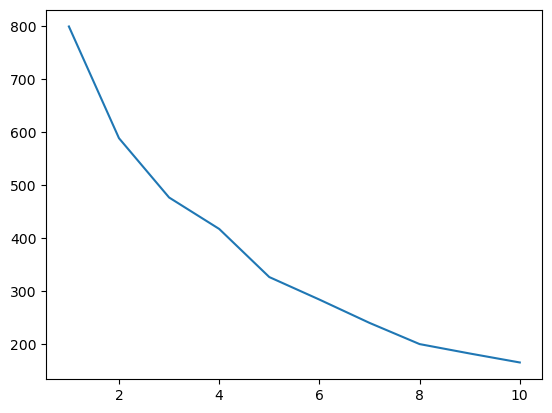

In [93]:
Inertia_Scores3=[]
for i in range(1,11):
    kmeans3 = KMeans(n_clusters=i)
    kmeans3.fit(dff)
    Inertia_Scores3.append(kmeans3.inertia_)
plt.plot(range(1,11),Inertia_Scores3)

In [94]:
df.to_csv('Clustering.csv')